In [1]:
!pip install pandas matplotlib seaborn scikit-learn

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv("rba-dataset.csv")
df.head()

,index,Login Timestamp,User ID,Round-Trip Time [ms],IP Address,Country,Region,City,ASN,User Agent String,Browser Name and Version,OS Name and Version,Device Type,Login Successful,Is Attack IP,Is Account Takeover
0,0,2020-02-03 12:43:30.772,-4324475583306591935,NaN,10.0.65.171,NO,-,-,29695,Mozilla/5.0 (iPhone; CPU iPhone OS 13_4 like ...,Firefox 20.0.0.1618,iOS 13.4,mobile,False,False,False
1,1,2020-02-03 12:43:43.549,-4324475583306591935,NaN,194.87.207.6,AU,-,-,60117,Mozilla/5.0 (Linux; Android 4.1; Galaxy Nexus...,Chrome Mobile 46.0.2490,Android 4.1,mobile,False,False,False
2,2,2020-02-03 12:43:55.873,-3284137479262433373,NaN,81.167.144.58,NO,Vestland,Urangsvag,29695,Mozilla/5.0 (iPad; CPU OS 7_1 like Mac OS X) ...,Android 2.3.3.2672,iOS 7.1,mobile,True,False,False
3,3,2020-02-03 12:43:56.180,-4324475583306591935,NaN,170.39.78.152,US,-,-,393398,Mozilla/5.0 (Linux; Android 4.1; Galaxy Nexus...,Chrome Mobile WebView 85.0.4183,Android 4.1,mobile,False,False,False
4,4,2020-02-03 12:43:59.396,-4618854071942621186,NaN,10.0.0.47,US,Virginia,Ashburn,398986,Mozilla/5.0 (Linux; U; Android 2.2) Build/NMA...,Chrome Mobile WebView 85.0.4183,Android 2.2,mobile,False,True,False


In [5]:
successful_logins = df['Login Successful'].sum()
print("Successful Logins:", successful_logins)

failed_logins = (~df['Login Successful']).sum()
print("Failed Logins:", failed_logins)

print("Total Events:", len(df))

Successful Logins: 12541442
Failed Logins: 18727822
Total Events: 31269264


In [6]:
suspicious_users = df[df['Is Attack IP'] == True]

print(suspicious_users[['User ID', 'IP Address']].head())

                User ID       IP Address
4  -4618854071942621186        10.0.0.47
5  -4324475583306591935  209.236.123.126
22  9133470655600090013    38.135.39.102
52 -3522288621475838107  209.236.117.198
60 -6623218066566818248     170.82.7.240


In [7]:
attack_count = df['Is Attack IP'].sum()
print("Attack Attempts:", attack_count)

Attack Attempts: 3096977


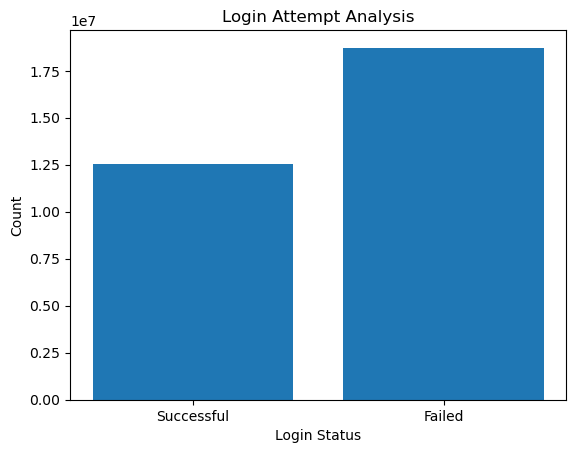

In [8]:
import matplotlib.pyplot as plt

labels = ['Successful', 'Failed']
values = [successful_logins, failed_logins]

plt.bar(labels, values)
plt.xlabel('Login Status')
plt.ylabel('Count')
plt.title('Login Attempt Analysis')
plt.show()

In [9]:
print(df.columns)

Index(['index', 'Login Timestamp', 'User ID', 'Round-Trip Time [ms]',
       'IP Address', 'Country', 'Region', 'City', 'ASN', 'User Agent String',
       'Browser Name and Version', 'OS Name and Version', 'Device Type',
       'Login Successful', 'Is Attack IP', 'Is Account Takeover'],
      dtype='object')


In [10]:
device_counts = df['Device Type'].value_counts()

print(device_counts)

Device Type
mobile     19642650
desktop     7934515
bot         2027834
unknown      867371
tablet       795368
Name: count, dtype: int64


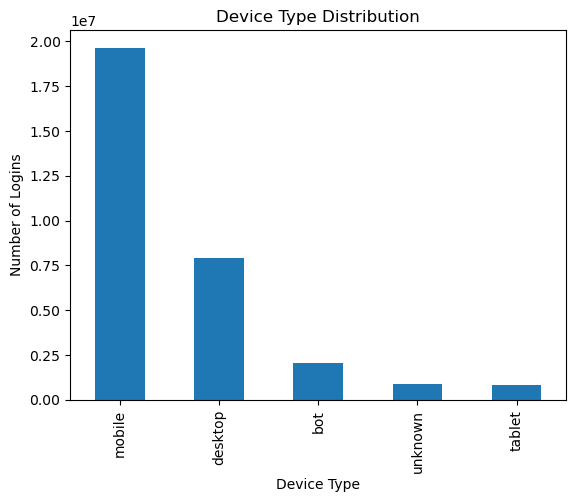

In [11]:
device_counts.plot(kind='bar')
plt.title('Device Type Distribution')
plt.xlabel('Device Type')
plt.ylabel('Number of Logins')
plt.show()

Country
NO    13216996
US     8685928
RU     1693250
BR     1181101
DE      897458
PL      854725
IN      438456
GB      422387
UA      406581
AU      392935
Name: count, dtype: int64


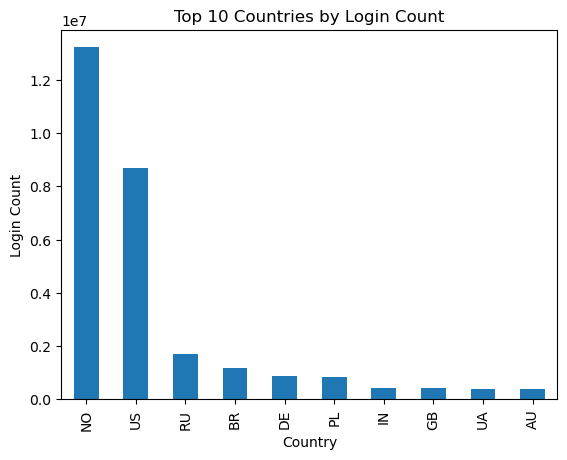

In [12]:
top_countries = df['Country'].value_counts().head(10)

print(top_countries)

top_countries.plot(kind='bar')
plt.title('Top 10 Countries by Login Count')
plt.xlabel('Country')
plt.ylabel('Login Count')
plt.show()

In [13]:
account_takeovers = df['Is Account Takeover'].sum()

print("Account Takeovers:", account_takeovers)

Account Takeovers: 141


In [14]:
suspicious_ips = df[df['Is Attack IP'] == True]['IP Address'].value_counts().head(10)

print(suspicious_ips)

IP Address
10.0.52.159        40188
10.0.9.48          13272
118.143.198.68      7354
209.236.125.192     3013
209.236.117.91      3001
209.236.125.179     2996
10.0.52.158         2968
209.236.123.172     2963
209.236.123.131     2955
66.248.237.208      2945
Name: count, dtype: int64


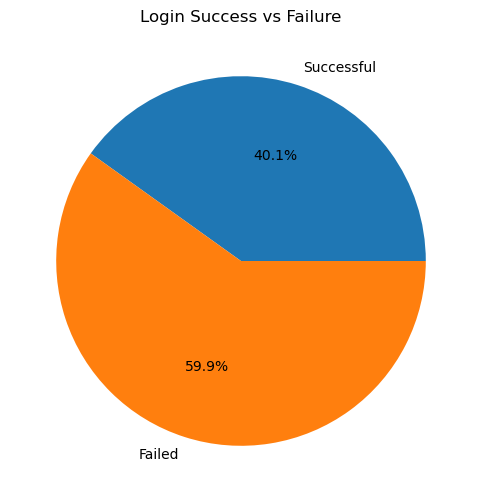

In [15]:
plt.figure(figsize=(6,6))

plt.pie(
    [successful_logins, failed_logins],
    labels=['Successful', 'Failed'],
    autopct='%1.1f%%'
)

plt.title('Login Success vs Failure')
plt.show()

In [16]:
top_browsers = df['Browser Name and Version'].value_counts().head(10)

print(top_browsers)

Browser Name and Version
ZipppBot 0.11                      1662964
Chrome Mobile 81.0.4044            1434241
Chrome 84.0.4147.338.339            864307
Opera Mobile 52.1.2254              850696
Android 2.3.3.2660                  778018
Chrome Mobile 81.0.4044.1925        728650
VLC 3.0.0-git                       708927
Chrome Mobile 81.0.4044.1927        687886
Chrome Mobile WebView 85.0.4183     681310
Chrome Mobile WebView 81.0.4044     665104
Name: count, dtype: int64


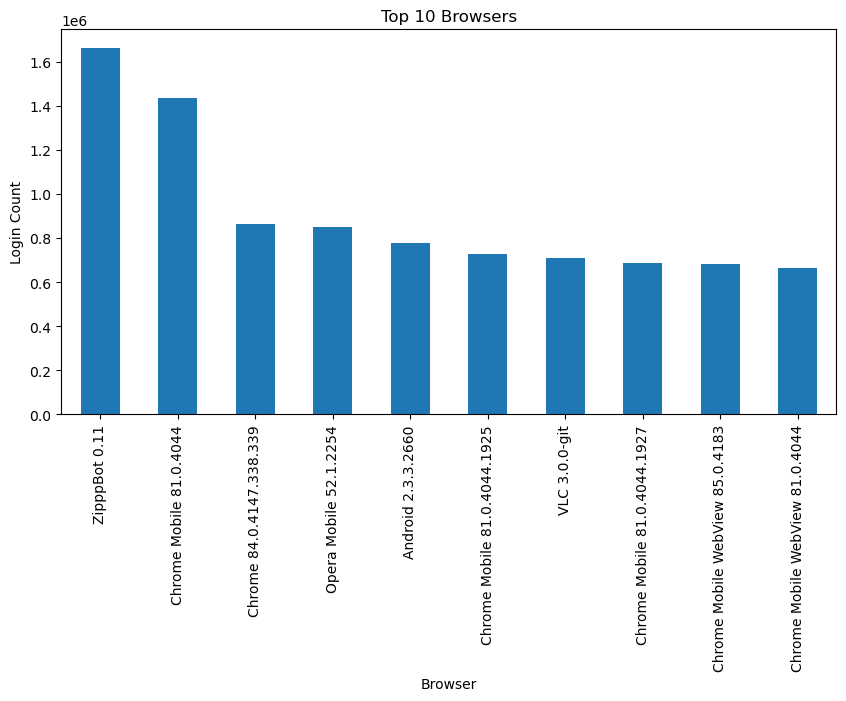

In [17]:
top_browsers.plot(kind='bar', figsize=(10,5))
plt.title("Top 10 Browsers")
plt.xlabel("Browser")
plt.ylabel("Login Count")
plt.show()

OS Name and Version
iOS 11.2.6          4406409
Mac OS X 10.14.6    4387221
iOS 13.4            3797427
Other               2883889
Android 4.1         1804833
Mac OS X 11.6.3     1484511
Android 2.2         1098129
Android 13.0         870800
Android 6.0.99       859770
iOS 14.2.1           836973
Name: count, dtype: int64


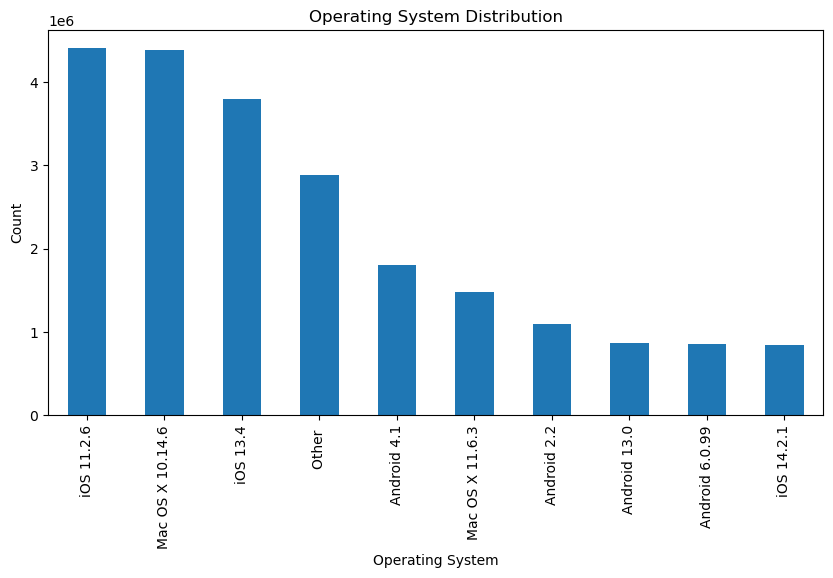

In [18]:
os_counts = df['OS Name and Version'].value_counts().head(10)

print(os_counts)

os_counts.plot(kind='bar', figsize=(10,5))
plt.title("Operating System Distribution")
plt.xlabel("Operating System")
plt.ylabel("Count")
plt.show()

In [19]:
attack_percentage = (attack_count / len(df)) * 100

print("Attack Percentage:", round(attack_percentage,2), "%")

takeover_count = df['Is Account Takeover'].sum()

takeover_percentage = (takeover_count / len(df)) * 100

print("Account Takeovers:", takeover_count)
print("Takeover Percentage:", round(takeover_percentage,2), "%")

Attack Percentage: 9.9 %
Account Takeovers: 141
Takeover Percentage: 0.0 %


In [20]:
print("\nLOGIN ATTEMPT ANALYSIS REPORT")
print("--------------------------------")
print("Total Events:", len(df))
print("Successful Logins:", successful_logins)
print("Failed Logins:", failed_logins)
print("Attack Attempts:", attack_count)
print("Account Takeovers:", takeover_count)
print("Attack Percentage:", round(attack_percentage,2), "%")


LOGIN ATTEMPT ANALYSIS REPORT
--------------------------------
Total Events: 31269264
Successful Logins: 12541442
Failed Logins: 18727822
Attack Attempts: 3096977
Account Takeovers: 141
Attack Percentage: 9.9 %


In [21]:
failed_users = df[df['Login Successful'] == False]['User ID'].value_counts().head(10)

print("Top 10 Users with Failed Logins:")
print(failed_users)

Top 10 Users with Failed Logins:
User ID
-4324475583306591935    14025895
 6998943612473066845       70026
-8897190181838729192        1315
-3550173317628772375        1155
 6665318783057062876        1001
 3170364966826867167         545
-1970209372401500323         515
 1385966394387934286         446
-7198559811247368245         445
 3332350113609679787         378
Name: count, dtype: int64


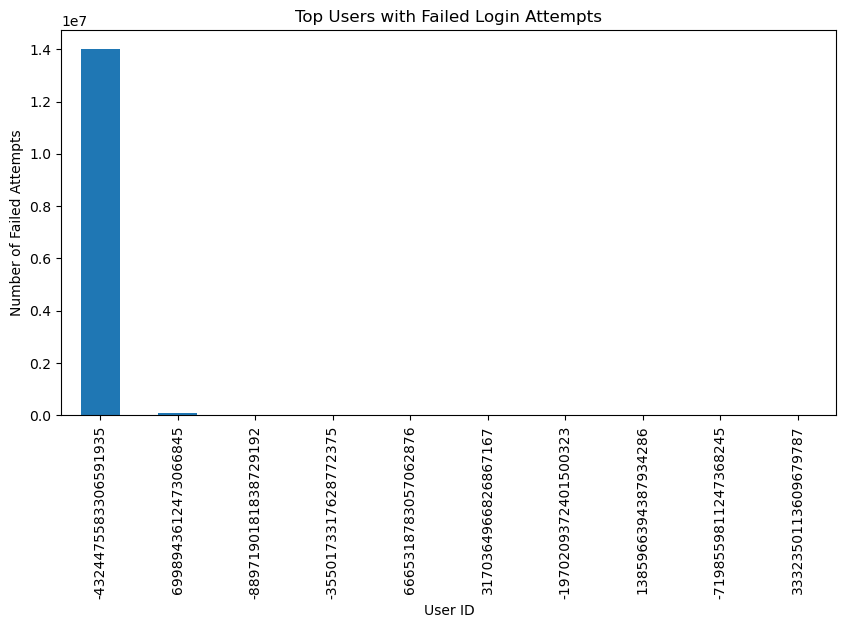

In [22]:
failed_users.plot(kind='bar', figsize=(10,5))
plt.title("Top Users with Failed Login Attempts")
plt.xlabel("User ID")
plt.ylabel("Number of Failed Attempts")
plt.show()

Top Attack IP Addresses:
IP Address
10.0.52.159        40188
10.0.9.48          13272
118.143.198.68      7354
209.236.125.192     3013
209.236.117.91      3001
209.236.125.179     2996
10.0.52.158         2968
209.236.123.172     2963
209.236.123.131     2955
66.248.237.208      2945
Name: count, dtype: int64


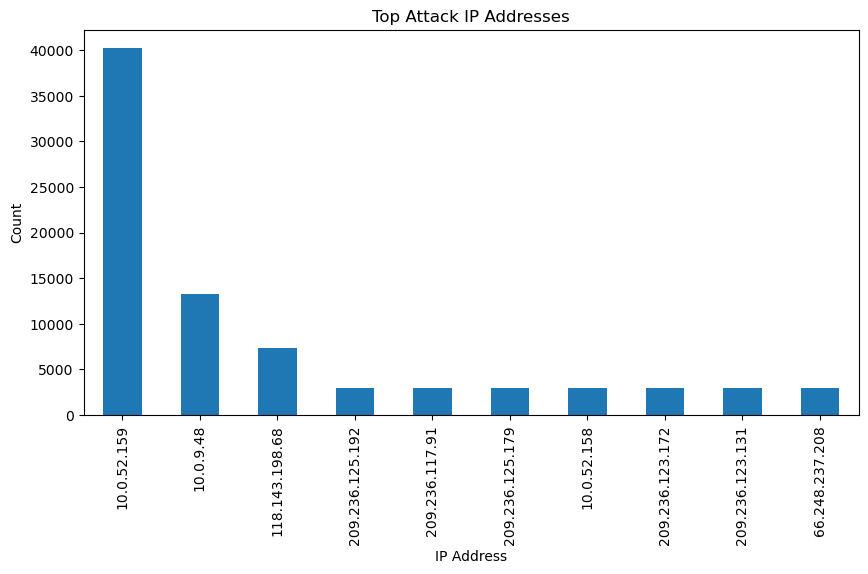

In [23]:
attack_ips = df[df['Is Attack IP'] == True]['IP Address'].value_counts().head(10)

print("Top Attack IP Addresses:")
print(attack_ips)

attack_ips.plot(kind='bar', figsize=(10,5))
plt.title("Top Attack IP Addresses")
plt.xlabel("IP Address")
plt.ylabel("Count")
plt.show()

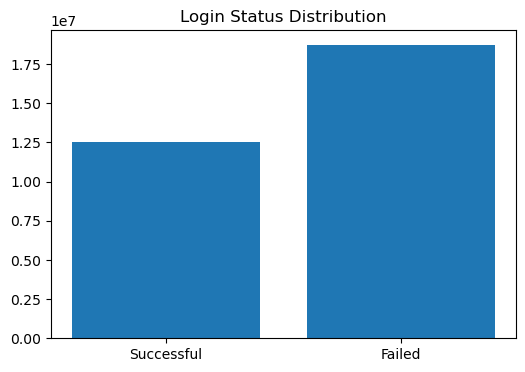

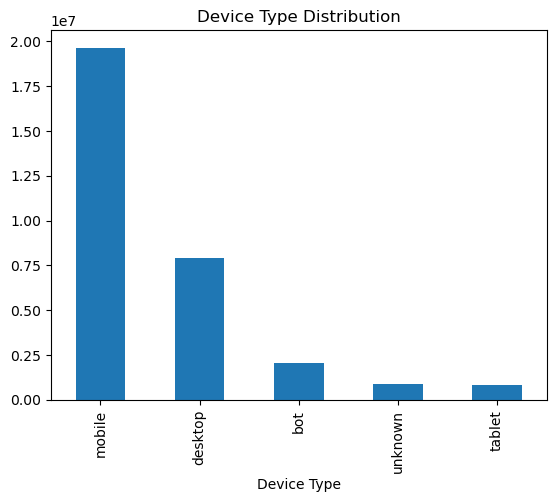

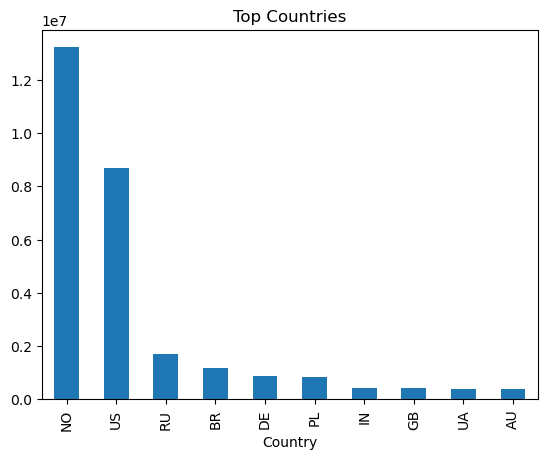

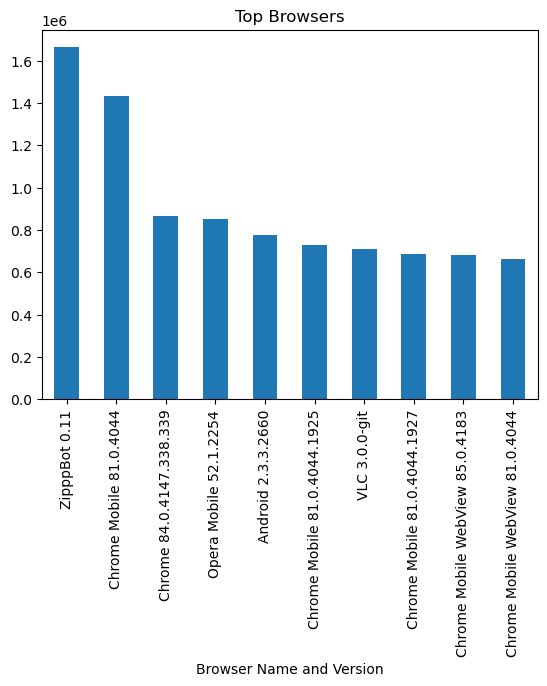

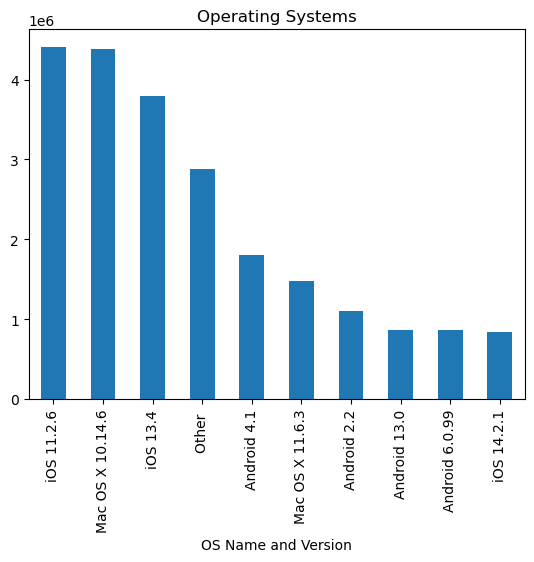

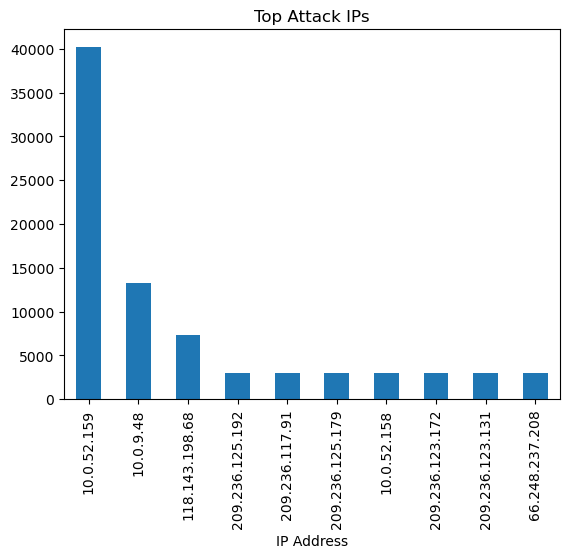

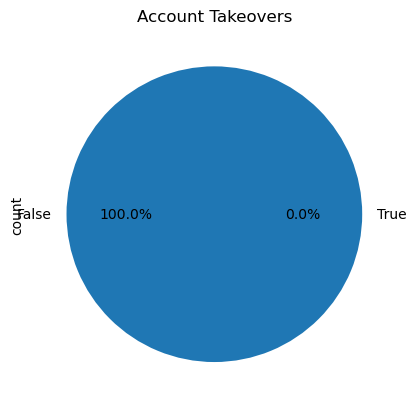

In [24]:
labels = ['Successful', 'Failed']
values = [successful_logins, failed_logins]

plt.figure(figsize=(6,4))
plt.bar(labels, values)
plt.title('Login Status Distribution')
plt.show()



df['Device Type'].value_counts().plot(kind='bar')
plt.title('Device Type Distribution')
plt.show()


df['Country'].value_counts().head(10).plot(kind='bar')
plt.title('Top Countries')
plt.show()



df['Browser Name and Version'].value_counts().head(10).plot(kind='bar')
plt.title('Top Browsers')
plt.show()



df['OS Name and Version'].value_counts().head(10).plot(kind='bar')
plt.title('Operating Systems')
plt.show()



df[df['Is Attack IP']==True]['IP Address'].value_counts().head(10).plot(kind='bar')
plt.title('Top Attack IPs')
plt.show()



df['Is Account Takeover'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title('Account Takeovers')
plt.show()

In [25]:
pip install matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


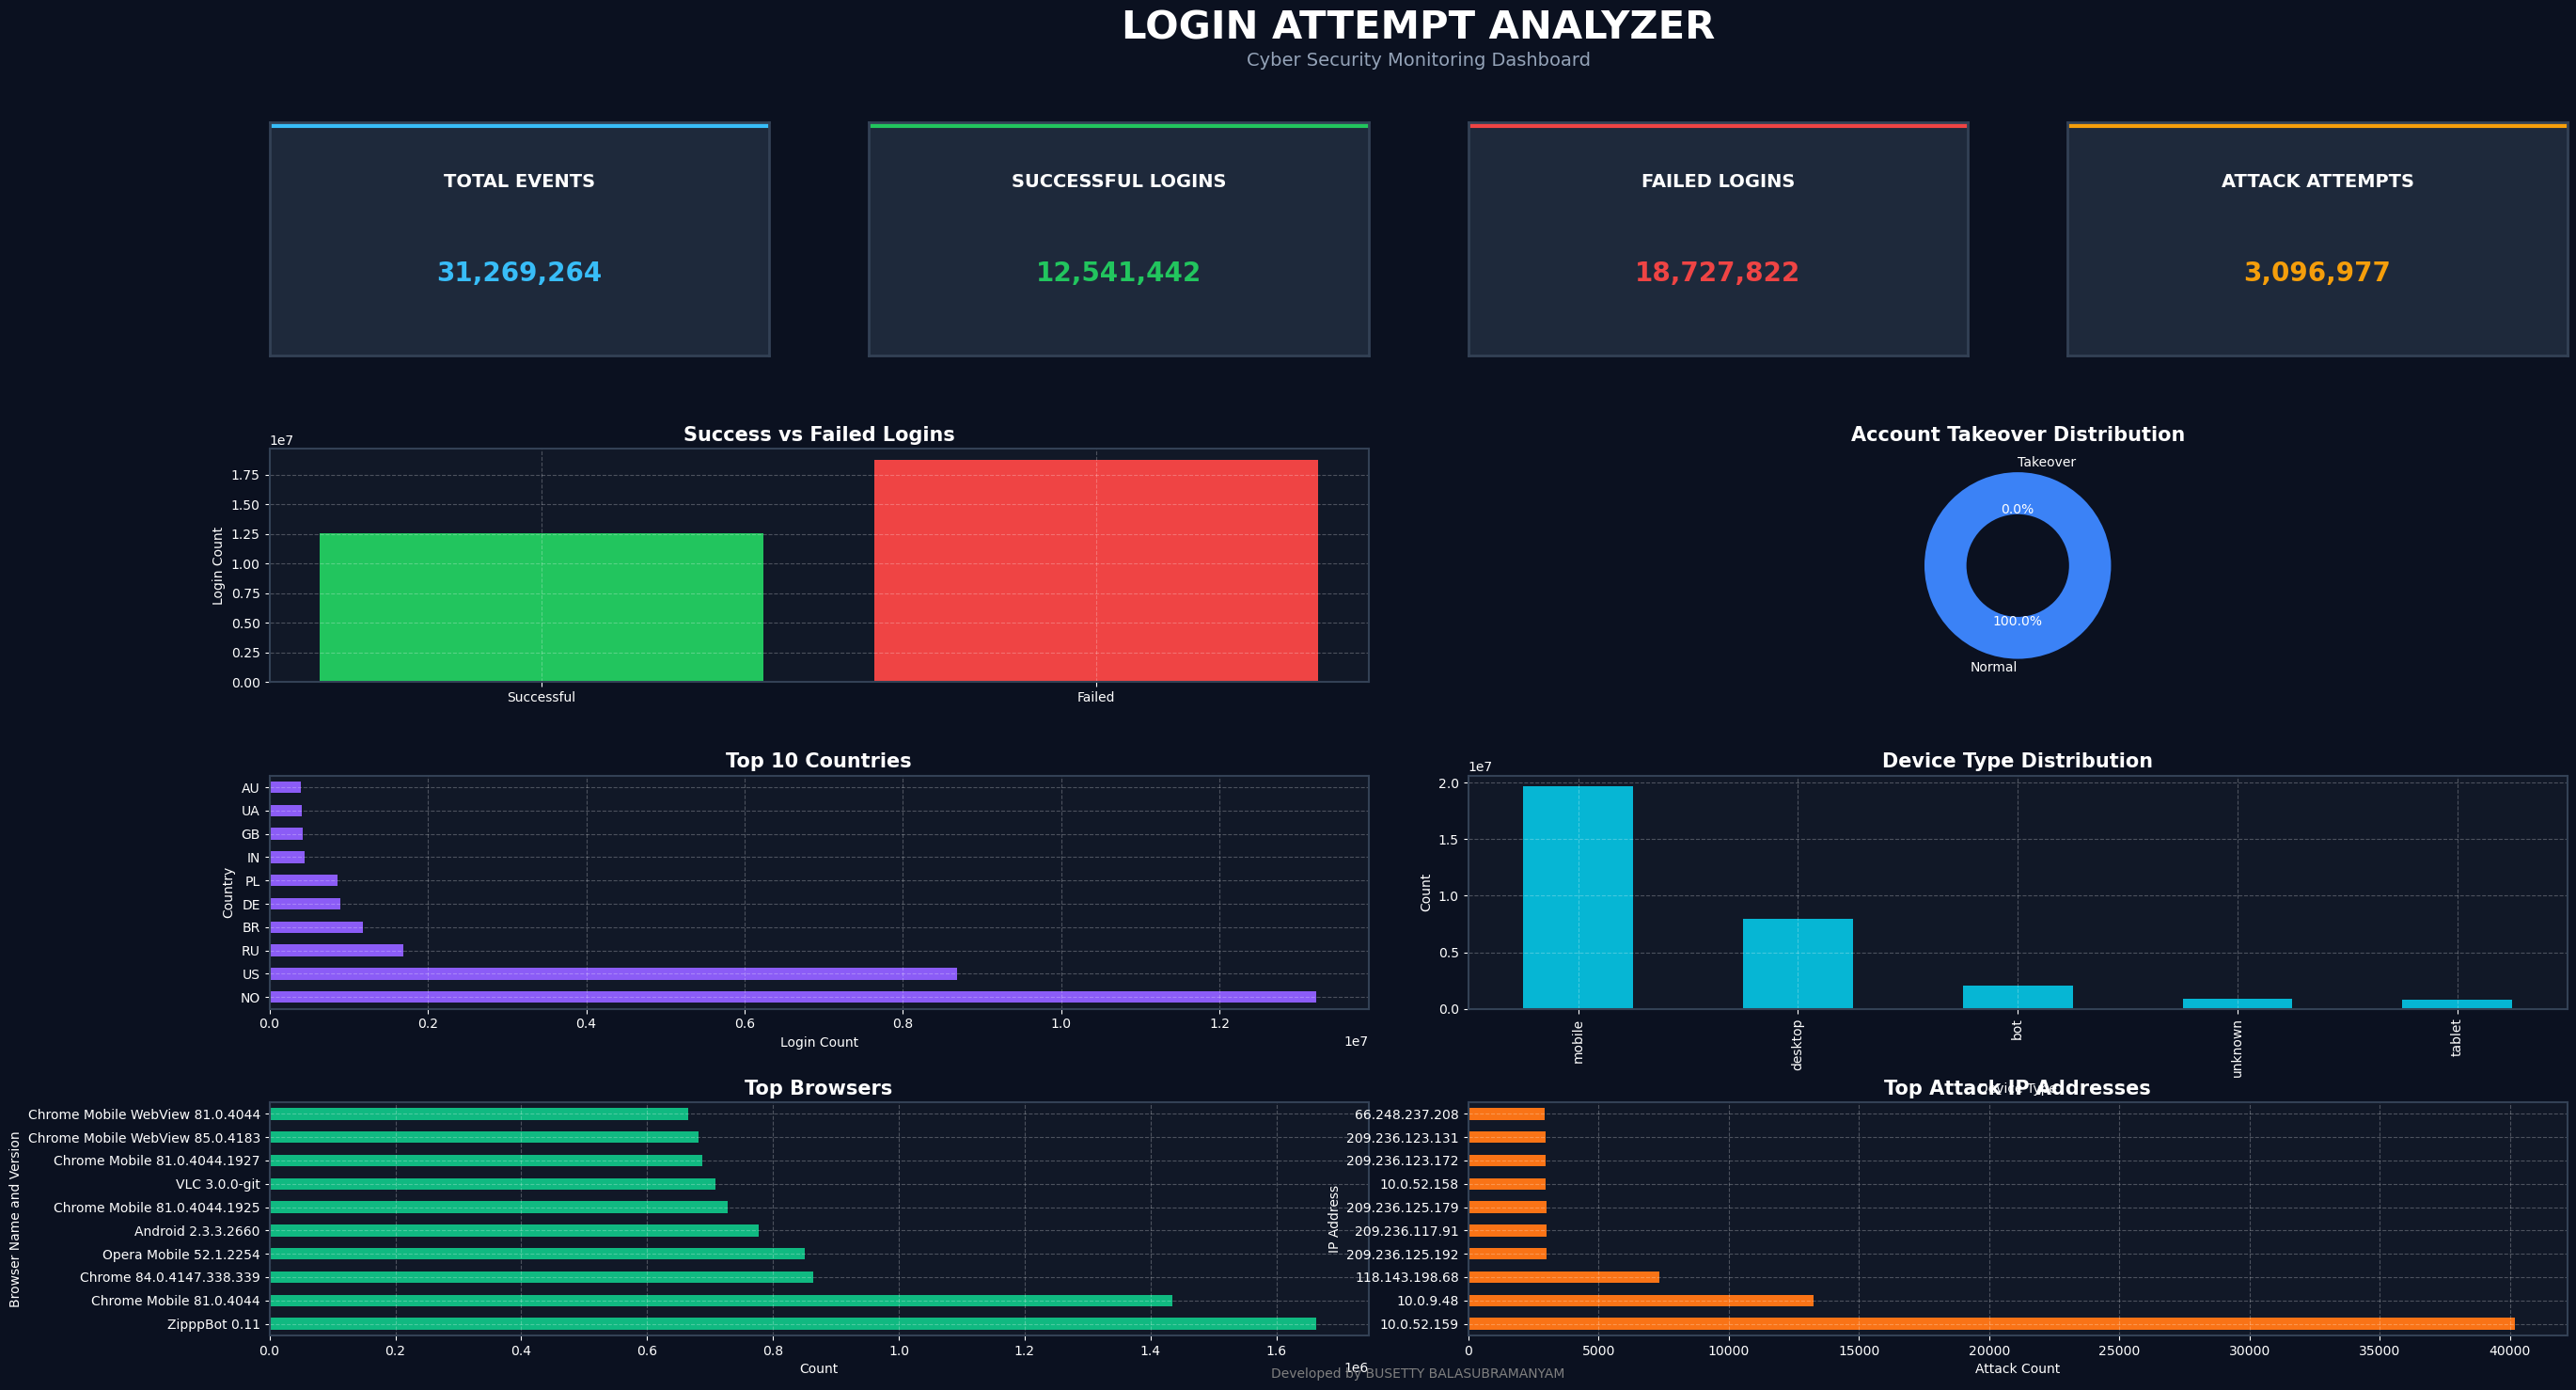

In [30]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

plt.style.use('dark_background')

# ================= COLORS =================
BG_COLOR = '#0B1120'
CARD_COLOR = '#1E293B'
BORDER_COLOR = '#334155'

SUCCESS_COLOR = '#22C55E'
FAILED_COLOR = '#EF4444'
ATTACK_COLOR = '#F59E0B'
TOTAL_COLOR = '#38BDF8'

# ================= FIGURE =================
fig = plt.figure(figsize=(26,15))
fig.patch.set_facecolor(BG_COLOR)

gs = GridSpec(4,4, figure=fig)

# ================= TITLE =================
fig.suptitle(
    "LOGIN ATTEMPT ANALYZER",
    fontsize=30,
    color='white',
    fontweight='bold'
)

fig.text(
    0.5,
    0.94,
    "Cyber Security Monitoring Dashboard",
    ha='center',
    fontsize=14,
    color='#94A3B8'
)

# ================= KPI CARDS =================
cards = [
    ("TOTAL EVENTS", total_events, TOTAL_COLOR),
    ("SUCCESSFUL LOGINS", successful_logins, SUCCESS_COLOR),
    ("FAILED LOGINS", failed_logins, FAILED_COLOR),
    ("ATTACK ATTEMPTS", attack_count, ATTACK_COLOR)
]

for i, (title, value, color) in enumerate(cards):

    ax = fig.add_subplot(gs[0, i])

    ax.set_facecolor(CARD_COLOR)

    for spine in ax.spines.values():
        spine.set_color(BORDER_COLOR)
        spine.set_linewidth(2)

    # top colored line
    ax.axhline(y=1, color=color, linewidth=8)

    ax.text(
        0.5,
        0.72,
        title,
        ha='center',
        fontsize=14,
        color='white',
        fontweight='bold'
    )

    ax.text(
        0.5,
        0.32,
        f"{value:,}",
        ha='center',
        fontsize=20,
        color=color,
        fontweight='bold'
    )

    ax.set_xticks([])
    ax.set_yticks([])

# =====================================================
# CHART 1 : SUCCESS VS FAILED
# =====================================================
ax1 = fig.add_subplot(gs[1,0:2])
ax1.set_facecolor('#111827')

bars = ax1.bar(
    ['Successful', 'Failed'],
    [successful_logins, failed_logins],
    color=[SUCCESS_COLOR, FAILED_COLOR]
)

ax1.set_title("Success vs Failed Logins", fontsize=15, fontweight='bold')
ax1.set_ylabel("Login Count")
ax1.grid(linestyle='--', alpha=0.25)

# =====================================================
# CHART 2 : DONUT CHART
# =====================================================
ax2 = fig.add_subplot(gs[1,2:4])
ax2.set_facecolor('#111827')

ax2.pie(
    account_takeover,
    labels=['Normal', 'Takeover'],
    autopct='%1.1f%%',
    startangle=90,
    colors=['#3B82F6', '#EF4444'],
    wedgeprops=dict(width=0.45)
)

ax2.set_title("Account Takeover Distribution", fontsize=15, fontweight='bold')

# =====================================================
# CHART 3 : COUNTRIES
# =====================================================
ax3 = fig.add_subplot(gs[2,0:2])
ax3.set_facecolor('#111827')

top_countries.plot(
    kind='barh',
    ax=ax3,
    color='#8B5CF6'
)

ax3.set_title("Top 10 Countries", fontsize=15, fontweight='bold')
ax3.set_xlabel("Login Count")
ax3.grid(linestyle='--', alpha=0.25)

# =====================================================
# CHART 4 : DEVICE TYPE
# =====================================================
ax4 = fig.add_subplot(gs[2,2:4])
ax4.set_facecolor('#111827')

device_counts.plot(
    kind='bar',
    ax=ax4,
    color='#06B6D4'
)

ax4.set_title("Device Type Distribution", fontsize=15, fontweight='bold')
ax4.set_ylabel("Count")
ax4.grid(linestyle='--', alpha=0.25)

# =====================================================
# CHART 5 : BROWSERS
# =====================================================
ax5 = fig.add_subplot(gs[3,0:2])
ax5.set_facecolor('#111827')

top_browsers.plot(
    kind='barh',
    ax=ax5,
    color='#10B981'
)

ax5.set_title("Top Browsers", fontsize=15, fontweight='bold')
ax5.set_xlabel("Count")
ax5.grid(linestyle='--', alpha=0.25)

# =====================================================
# CHART 6 : ATTACK IPs
# =====================================================
ax6 = fig.add_subplot(gs[3,2:4])
ax6.set_facecolor('#111827')

top_attack_ips.plot(
    kind='barh',
    ax=ax6,
    color='#F97316'
)

ax6.set_title("Top Attack IP Addresses", fontsize=15, fontweight='bold')
ax6.set_xlabel("Attack Count")
ax6.grid(linestyle='--', alpha=0.25)

# ================= CHART BORDERS =================
for ax in [ax1, ax3, ax4, ax5, ax6]:
    for spine in ax.spines.values():
        spine.set_color(BORDER_COLOR)
        spine.set_linewidth(1.5)

# ================= SPACING =================
plt.subplots_adjust(
    left=0.03,
    right=0.97,
    top=0.90,
    bottom=0.04,
    hspace=0.40,
    wspace=0.20
)

# ================= FOOTER =================
fig.text(
    0.5,
    0.01,
    "Developed by BUSETTY BALASUBRAMANYAM",
    ha='center',
    fontsize=10,
    color='gray'
)

plt.show()